<a href="https://colab.research.google.com/github/anuragkba2027-lab/MIOM_Project/blob/anurag-process-control/notebooks/MIOM_standardized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIOM Project: SECom Dataset Analysis

Semiconductor yield prediction with anomaly detection (DBSCAN/KMeans), PCA, time-series.

**Run in venv with `jupyter notebook notebooks/MIOM_standardized.ipynb`**

## Imports

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (path / 'data').exists()),
    Path.cwd().resolve(),
)
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
TEMP_DIR = DATA_DIR / 'secom_temp'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
TEMP_DIR.mkdir(parents=True, exist_ok=True)

# Style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

## 1. Data Loading & Extraction

In [ ]:
def load_and_extract_data(zip_path: Path | None = None, extract_dir: Path | None = None) -> pd.DataFrame:
    zip_path = Path(zip_path) if zip_path else RAW_DIR / 'secom.zip'
    extract_dir = Path(extract_dir) if extract_dir else TEMP_DIR
    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    # Load space-separated data
    data_path = extract_dir / 'secom.data'
    df = pd.read_csv(data_path, sep=r'\s+', header=None)
    df.columns = [f'feature_{i}' for i in range(df.shape[1])]
    return df

df_raw = load_and_extract_data()
if df_raw is not None:
    print(df_raw.shape)
    df_raw.head()

(1567, 590)


## 2. EDA - Missing Values

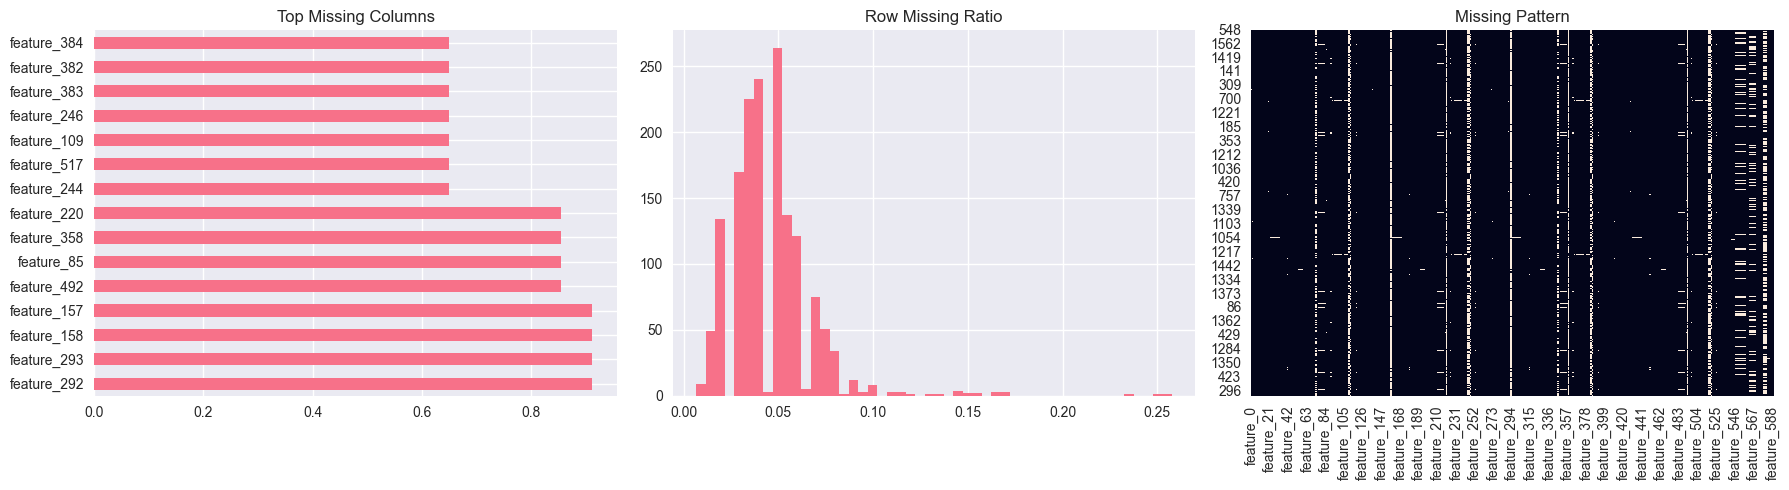

In [ ]:
def plot_missing_analysis(df: pd.DataFrame):
    """Plot missing value analysis."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Col missing
    missing_cols = df.isnull().mean().sort_values(ascending=False).head(15)
    missing_cols.plot(kind='barh', ax=axes[0])
    axes[0].set_title('Top Missing Columns')

    # Row missing hist
    row_missing = df.isnull().mean(axis=1)
    row_missing.hist(bins=50, ax=axes[1])
    axes[1].set_title('Row Missing Ratio')

    # Heatmap
    sample_size = min(len(df), 500)
    sns.heatmap(df.sample(sample_size, random_state=42).isnull(), cbar=False, ax=axes[2])
    axes[2].set_title('Missing Pattern')

    plt.tight_layout()
    plt.show()

if 'df_raw' in locals(): plot_missing_analysis(df_raw)

## 3. Preprocessing

In [ ]:
def preprocess_data(df: pd.DataFrame, missing_threshold: float = 0.5) -> tuple:
    """Impute missing, add indicators, drop constants."""
    # Filter high-missing cols
    missing_ratio = df.isnull().mean()
    cols_keep = missing_ratio[missing_ratio < missing_threshold].index
    df_clean = df[cols_keep].copy()

    # Missing indicators
    missing_ind = df_clean.isnull().astype(int)
    missing_ind.columns = [col + '_missing' for col in df_clean.columns]

    # Median impute
    df_imputed = df_clean.fillna(df_clean.median())

    # Combine
    df_processed = pd.concat([df_imputed, missing_ind], axis=1)

    # Drop constants
    cols_drop = []
    for col in df_processed.columns:
        if df_processed[col].nunique() == 1:
            cols_drop.append(col)
    df_processed = df_processed.drop(columns=set(cols_drop))

    # Save
    df_imputed.to_csv(PROCESSED_DIR / 'Cleaned_data.csv', index=False)
    df_processed.to_csv(PROCESSED_DIR / 'Cleaned_data_Indicated.csv', index=False)

    return df_imputed, df_processed

if 'df_raw' in locals(): df_imputed, df_processed = preprocess_data(df_raw)
if 'df_processed' in locals(): print(df_processed.shape)

(1567, 956)


## 4. Scaling & PCA

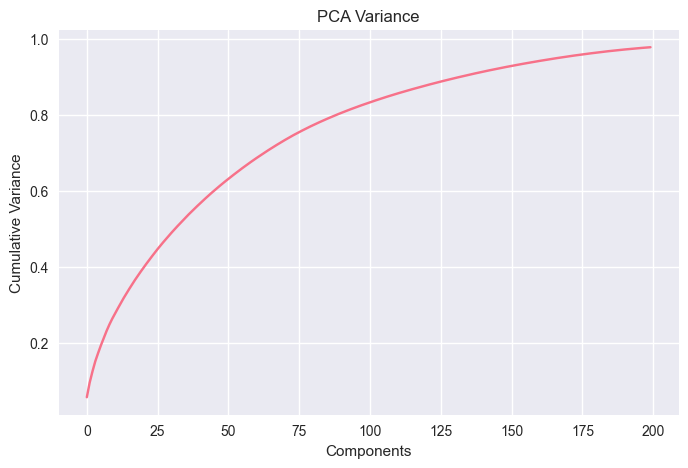

200 PCs retain 97.9% variance


In [ ]:
def apply_scaling_pca(df: pd.DataFrame, n_components: int = 200) -> pd.DataFrame:
    """Scale features, apply PCA."""
    original_cols = [col for col in df.columns if not col.endswith('_missing')]
    missing_cols = [col for col in df.columns if col.endswith('_missing')]

    scaler = StandardScaler()
    scaled_original = pd.DataFrame(
        scaler.fit_transform(df[original_cols]),
        columns=original_cols
    )

    df_scaled = pd.concat([scaled_original, df[missing_cols].reset_index(drop=True)], axis=1)
    df_scaled.to_csv(PROCESSED_DIR / 'Final_Scaled_data_Indicated.csv', index=False)

    # PCA
    n_components = min(n_components, df_scaled.shape[0], df_scaled.shape[1])
    pca = PCA(n_components=n_components)
    df_pca = pca.fit_transform(df_scaled)
    df_pca = pd.DataFrame(df_pca, columns=[f'PC_{i}' for i in range(n_components)])
    df_pca.to_csv(PROCESSED_DIR / 'secom_pca_ready.csv', index=False)

    # Scale PCA
    scaler_pca = StandardScaler()
    df_pca_scaled = pd.DataFrame(
        scaler_pca.fit_transform(df_pca),
        columns=df_pca.columns
    )
    df_pca_scaled.to_csv(PROCESSED_DIR / 'secom_pca_scaled.csv', index=False)

    # Plot variance
    fig, ax = plt.subplots(figsize=(8,5))
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    ax.plot(cum_var)
    ax.set_xlabel('Components')
    ax.set_ylabel('Cumulative Variance')
    ax.set_title('PCA Variance')
    ax.grid(True)
    plt.show()

    print(f"{n_components} PCs retain {cum_var[n_components - 1]*100:.1f}% variance")
    return df_pca_scaled

if 'df_processed' in locals(): df_pca_scaled = apply_scaling_pca(df_processed)

## 5. Clustering & Anomaly Detection

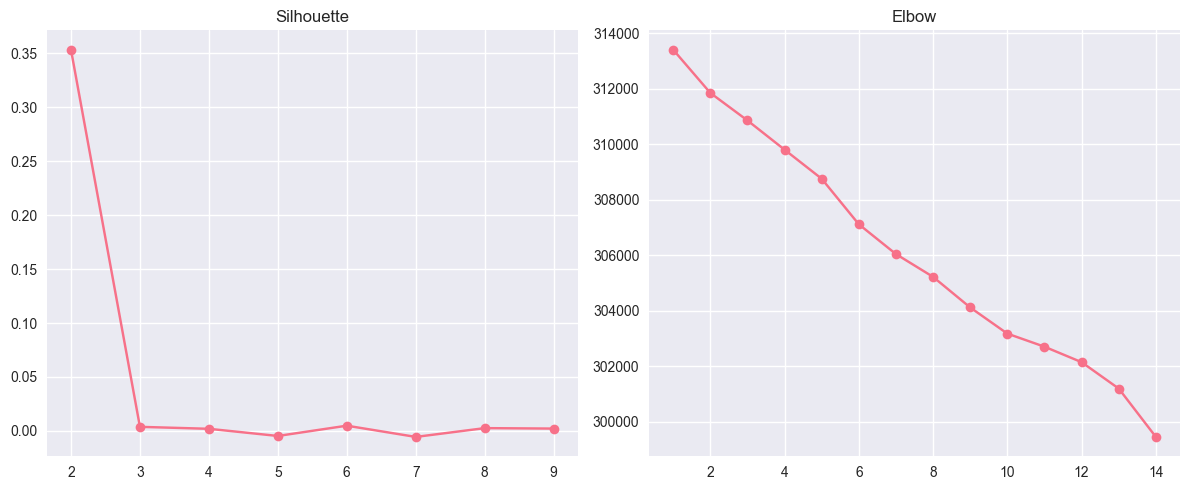

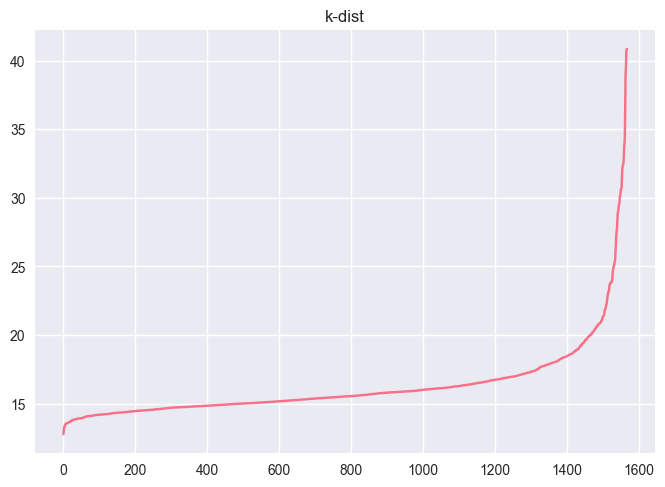

Clusters: cluster
1    1563
0       4
Name: count, dtype: int64
DBSCAN:  0    1227
-1     340
Name: count, dtype: int64


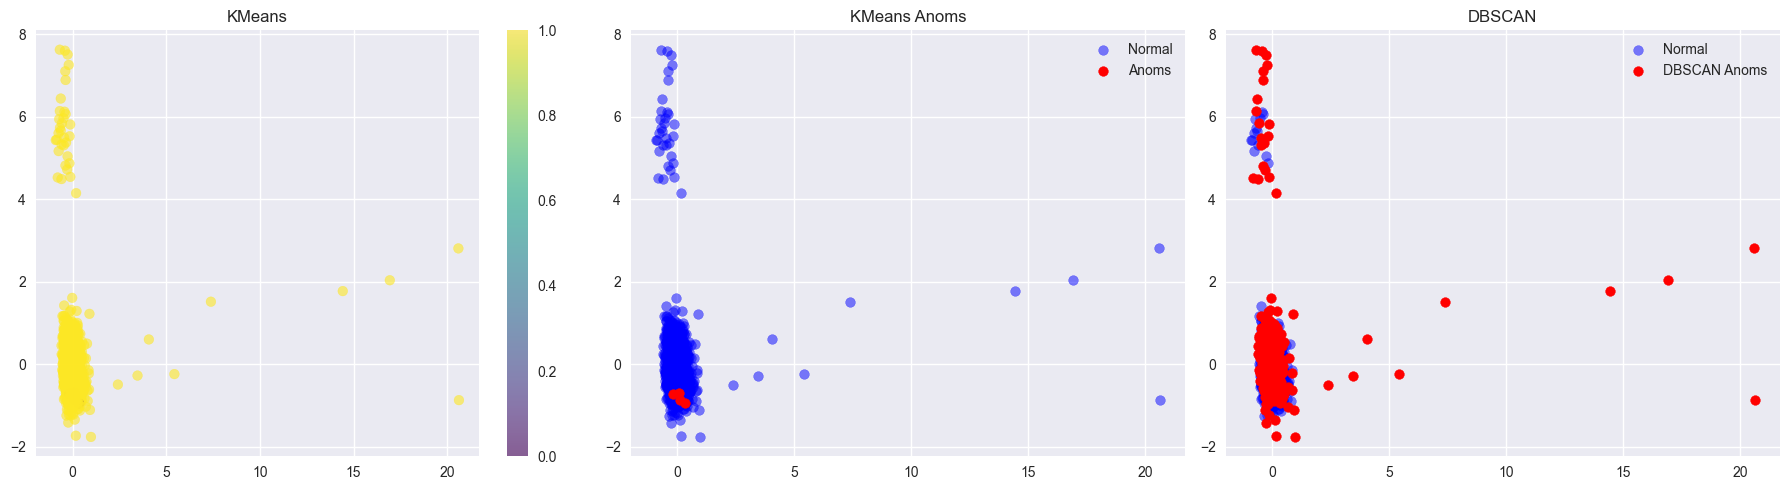

In [ ]:
def cluster_and_detect(df_pca: pd.DataFrame) -> pd.DataFrame:
    """KMeans + DBSCAN."""
    # KMeans silhouette
    scores = []
    for k in range(2, 10):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(df_pca)
        scores.append(silhouette_score(df_pca, labels))

    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    axes[0].plot(range(2,10), scores, 'o-')
    axes[0].set_title('Silhouette')

    # Elbow
    inertia = []
    for k in range(1,15):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(df_pca)
        inertia.append(kmeans.inertia_)
    axes[1].plot(range(1,15), inertia, 'o-')
    axes[1].set_title('Elbow')
    plt.tight_layout()
    plt.show()

    # KMeans k=2
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(df_pca)

    # DBSCAN tuning
    neighbors = NearestNeighbors(n_neighbors=10)
    nbrs = neighbors.fit(df_pca)
    distances, _ = nbrs.kneighbors(df_pca)
    plt.plot(np.sort(distances[:,9]));
    plt.title('k-dist')
    plt.show()

    dbscan = DBSCAN(eps=16, min_samples=10)
    labels_db = dbscan.fit_predict(df_pca)

    df_results = pd.DataFrame(df_pca, columns=[f'PC_{i}' for i in range(df_pca.shape[1])])
    df_results['cluster'] = clusters
    df_results['dbscan_label'] = labels_db
    print('Clusters:', df_results['cluster'].value_counts())
    print('DBSCAN:', pd.Series(labels_db).value_counts())

    # Plots
    fig, axes = plt.subplots(1,3, figsize=(18,5))
    scatter = axes[0].scatter(df_results['PC_0'], df_results['PC_1'], c=df_results['cluster'], cmap='viridis', alpha=0.6)
    axes[0].set_title('KMeans')
    plt.colorbar(scatter, ax=axes[0])

    axes[1].scatter(df_results['PC_0'], df_results['PC_1'], c='blue', alpha=0.5, label='Normal')
    anom_k = df_results[df_results['cluster']==0]
    axes[1].scatter(anom_k['PC_0'], anom_k['PC_1'], c='red', label='Anoms')
    axes[1].legend()
    axes[1].set_title('KMeans Anoms')

    normal = df_results[df_results['dbscan_label'] != -1]
    axes[2].scatter(normal['PC_0'], normal['PC_1'], c='blue', alpha=0.5, label='Normal')
    anom_db = df_results[df_results['dbscan_label'] == -1]
    axes[2].scatter(anom_db['PC_0'], anom_db['PC_1'], c='red', label='DBSCAN Anoms')
    axes[2].legend()
    axes[2].set_title('DBSCAN')
    plt.tight_layout()
    plt.show()

    return df_results

if 'df_pca_scaled' in locals(): df_results = cluster_and_detect(df_pca_scaled)

## 6. Time-Series & Evaluation

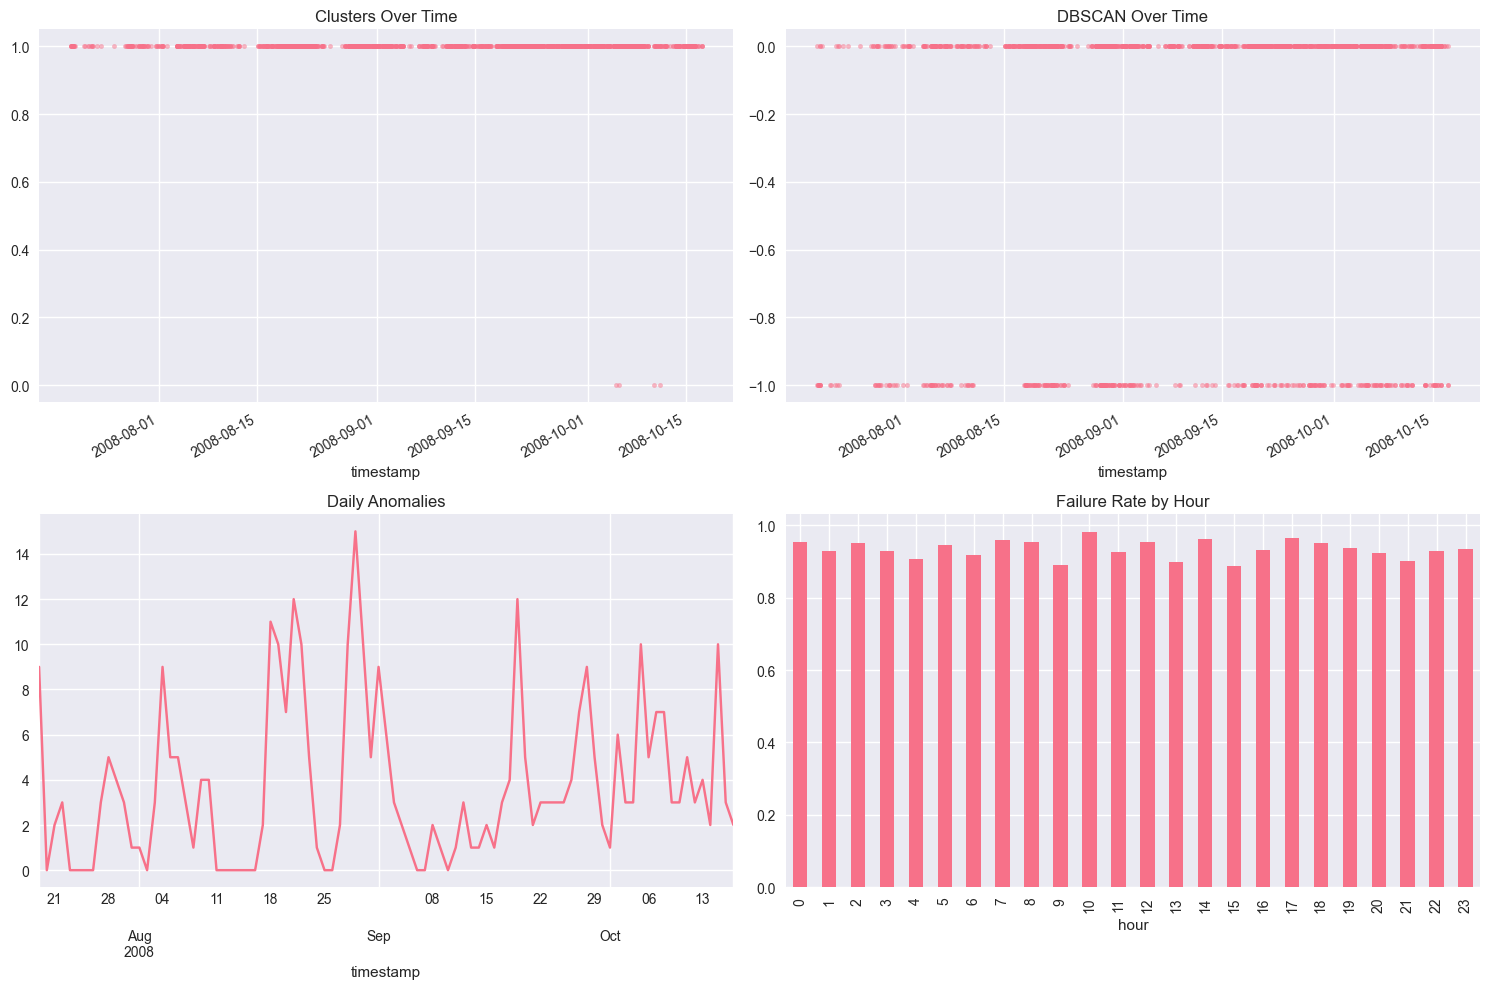

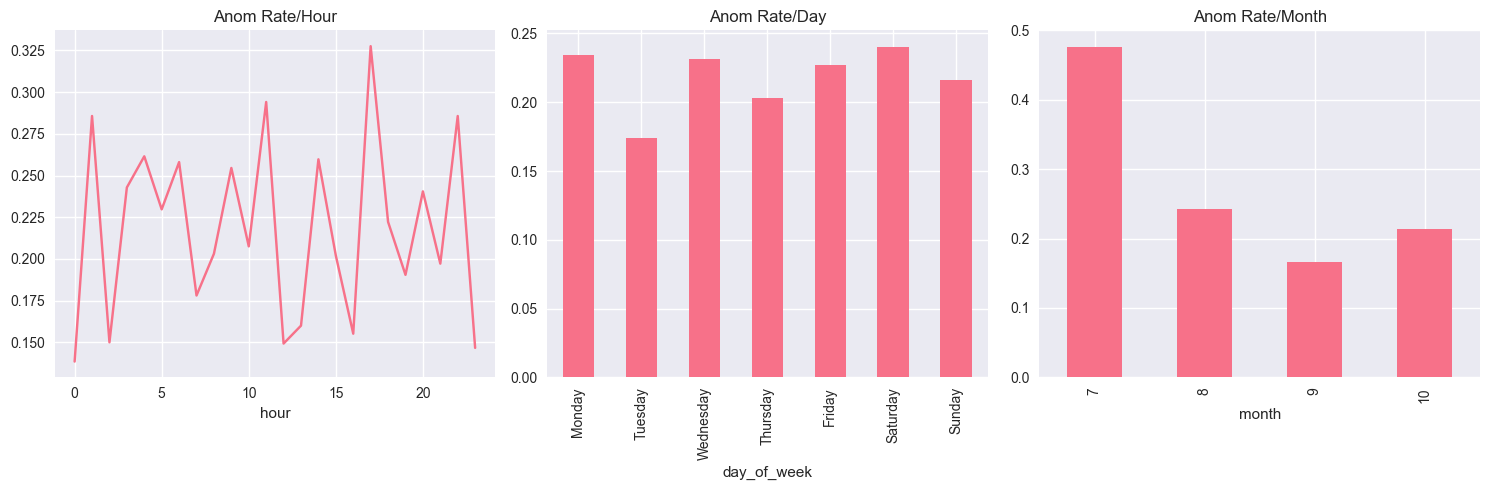

Precision (next failure | anomaly): 0.914
Recall (anomaly | next failure): 0.212
Top differing features:
feature_162    527.058658
feature_159    274.919196
feature_23     268.793938
feature_24     267.711032
feature_297    254.041969
feature_161    227.335956
feature_160    165.865705
feature_21     155.402392
feature_204    147.034436
feature_294    131.817234
dtype: float64


In [ ]:
def time_analysis(df_results: pd.DataFrame, df_processed: pd.DataFrame):
    """Load labels, analyze over time."""
    label_candidates = [
        RAW_DIR / 'secom_labels.csv',
        TEMP_DIR / 'secom_labels.data',
        PROJECT_ROOT / 'secom_labels.csv',
    ]
    labels_path = next((path for path in label_candidates if path.exists()), None)
    if labels_path is None:
        raise FileNotFoundError('Could not locate a SECOM labels file.')

    if labels_path.suffix == '.csv':
        labels = pd.read_csv(labels_path).rename(columns={'label': 'true_label', 'date': 'timestamp'})
    else:
        labels = pd.read_csv(labels_path, sep=r'\s+', header=None, names=['true_label', 'timestamp'])

    labels = labels[['true_label', 'timestamp']]
    labels['timestamp'] = pd.to_datetime(labels['timestamp'], dayfirst=True)

    df_time = df_results.copy()
    df_time['true_label'] = labels['true_label']
    df_time['timestamp'] = labels['timestamp']
    df_time = df_time.sort_values('timestamp')

    df_time['is_anomaly'] = (df_time['dbscan_label'] == -1).astype(int)
    df_time['is_failure'] = (df_time['true_label'] == -1).astype(int)

    # Temporal features
    df_time['hour'] = df_time['timestamp'].dt.hour
    df_time['day_of_week'] = df_time['timestamp'].dt.day_name()
    df_time['month'] = df_time['timestamp'].dt.month

    # Plots over time
    fig, axes = plt.subplots(2,2, figsize=(15,10))
    df_time.set_index('timestamp')['cluster'].plot(style='.', ax=axes[0,0], alpha=0.5)
    axes[0,0].set_title('Clusters Over Time')

    df_time.set_index('timestamp')['dbscan_label'].plot(style='.', ax=axes[0,1], alpha=0.5)
    axes[0,1].set_title('DBSCAN Over Time')

    daily_anoms = df_time.set_index('timestamp').resample('D')['is_anomaly'].sum()
    daily_anoms.plot(ax=axes[1,0], title='Daily Anomalies')

    hour_fail = df_time.groupby('hour')['is_failure'].mean()
    hour_fail.plot(kind='bar', ax=axes[1,1], title='Failure Rate by Hour')
    plt.tight_layout()
    plt.show()

    order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    fig, axes = plt.subplots(1,3, figsize=(15,5))
    df_time.groupby('hour')['is_anomaly'].mean().plot(ax=axes[0], title='Anom Rate/Hour')
    df_time.groupby('day_of_week')['is_anomaly'].mean().reindex(order_days).plot(kind='bar', ax=axes[1], title='Anom Rate/Day')
    df_time.groupby('month')['is_anomaly'].mean().plot(kind='bar', ax=axes[2], title='Anom Rate/Month')
    plt.tight_layout()
    plt.show()

    # Evaluation
    df_time['future_failure'] = df_time['is_failure'].shift(-1)
    precision = df_time[df_time['is_anomaly'] == 1]['future_failure'].mean()
    recall = df_time[df_time['future_failure'] == 1]['is_anomaly'].mean()
    print(f"Precision (next failure | anomaly): {precision:.3f}")
    print(f"Recall (anomaly | next failure): {recall:.3f}")

    # Anomaly feature diffs
    df_scaled_num = df_processed.select_dtypes(include=[np.number])
    anom_idx = df_time[df_time['dbscan_label'] == -1].index
    anoms = df_scaled_num.iloc[anom_idx]
    normal = df_scaled_num.drop(anom_idx)
    diff = (anoms.mean() - normal.mean()).abs().sort_values(ascending=False).head(10)
    print("Top differing features:")
    print(diff)

    return df_time

if 'df_results' in locals() and 'df_processed' in locals(): df_time = time_analysis(df_results, df_processed)

## Summary
- Processed data saved to `data/processed/`
- DBSCAN eps=16 detects anomalies predictive of future failures (precision/recall shown above).
- Ready for modeling.